In [2]:
import pandas as pd #mengolah data (DataFrame)
import numpy as np #operasi numerik
import matplotlib.pyplot as plt #visualisasi grafik
from sklearn.linear_model import LinearRegression #membuat model regresi linear
from sklearn.model_selection import train_test_split #membagi data training & testing
from sklearn import metrics #evaluasi model

In [3]:
df = pd.read_csv('/content/IceCreamData.csv')
df.head()

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


Membaca dataset Ice Cream Revenue
df.head() menampilkan 5 data pertama untuk melihat struktur data
Dataset yang berisi:Temperature (input) dan Revenue (output)

In [4]:
X = df[['Temperature']] #variabel independen (suhu)
y = df['Revenue'] #variabel dependen (pendapatan)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data dibagi menjadi:
*   80% training
*   20% testing

random_state=42 agar hasil konsisten

In [6]:
model = LinearRegression() #Membuat model regresi linear
model.fit(X_train, y_train) #fit() digunakan untuk melatih model

LinearRegression()

In [7]:
print("Intercept (a):", model.intercept_) #Intercept (a): Nilai revenue saat suhu = 0
print("Koefisien (b):", model.coef_[0]) #Koefisien (b): perubahan revenue tiap kenaikan 1°C

Intercept (a): 46.80464127742374
Koefisien (b): 21.38197385529505


In [8]:
y_pred = model.predict(X_test)
print("Data Testing (Temperature):")
print(X_test)

print("Revenue Asli:", y_test.values)
print("Revenue Prediksi:", y_pred)


Data Testing (Temperature):
     Temperature
361    29.704183
73     27.375401
374    23.984641
155    21.144047
104    26.595054
..           ...
347    24.960446
86     27.780500
75     28.790101
438    17.132795
15     18.483141

[100 rows x 1 columns]
Revenue Asli: [659.8732869  623.2487008  559.1358692  497.7523178  627.9018411
 300.9322734  278.7319615  319.3494624  483.4897686  683.5447809
 737.8008241  401.9247923  441.0029443  654.7474611   32.54661902
 221.400252   524.7463643  528.3804165  587.2212461  643.0909437
 584.399945   809.3525195  607.8391938  596.8767502  918.3912316
 636.298374   306.0907189  612.8037704  711.1740653  684.8030705
 453.7856066  416.8486183  684.1584437  809.7777259  660.6322888
 508.7204715  818.135393   276.787086   272.8570213  131.6570175
 583.8552306  221.2232906  501.34533    383.9562396  418.1372788
 591.1733898  534.7990284   71.16015301 477.3151879  524.2361154
 643.6486011  488.1708088  417.3548387  493.2266364  542.6080704
 623.5988607  

In [9]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 19.184547408370435
MSE: 652.5200612979734
RMSE: 25.544472225864705


In [10]:
prediksi = model.predict([[12]])
print("Prediksi revenue pada suhu 12°C:", prediksi[0])

Prediksi revenue pada suhu 12°C: 303.3883275409643


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


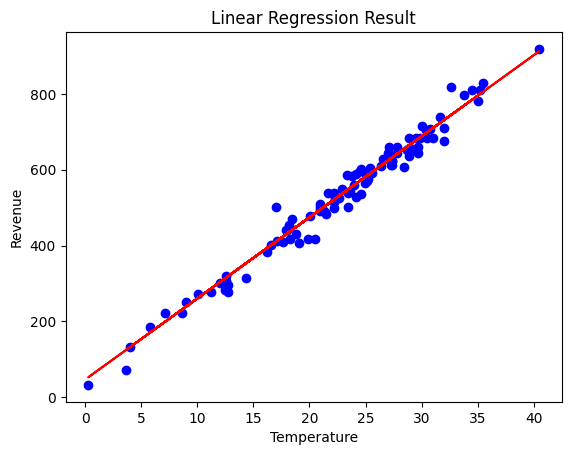

In [11]:

plt.scatter(X_test, y_test, color='blue') #Titik biru: data asli
plt.plot(X_test, y_pred, color='red') #Garis merah: hasil model regresi
plt.xlabel('Temperature')
plt.ylabel('Revenue')
plt.title('Linear Regression Result')
plt.show()

Grafik menunjukkan bahwa terdapat hubungan linear positif antara suhu dan pendapatan, di mana semakin tinggi temperature maka revenue juga meningkat. Hal ini terlihat dari garis regresi (merah) yang mengikuti pola sebaran data (titik biru). Selain itu, posisi titik yang cukup dekat dengan garis menunjukkan bahwa model memiliki tingkat kesalahan yang kecil, sehingga dapat disimpulkan bahwa model regresi linear yang digunakan sudah cukup baik dan mampu memprediksi revenue berdasarkan suhu dengan akurat.